# Lab 3: Proximal Gradient and Accelerated Methods

**Student: Viktoriia Vlasenko, 2088928**

In [2]:
import numpy as np
from numpy.linalg import norm 
import matplotlib.pyplot as plt

rnd_state = np.random.RandomState(12)

## Introduction: Proximal gradient
Let us define the proximity operator as follows
$$
\text{prox}_{\lambda g}(v ) = \arg \min\limits_{x \in \mathbb{R}^d} \Big\{ g(x) + \frac{1}{2 \lambda} \| x - v \|^2 \Big\}
$$
Given a point $v \in \mathbb{R}^d$, $\text{prox}_{\lambda g}(v)$ is a point close to $v$ and towards a minimizer of $g$. The parameter $\lambda$ can be interpreted as a relative weight between the two terms.

Furthermore, it is possible to prove that $x^*$ minimizes $g$ if and only if $x^*$ is a fixed point of the operator i.e.
$$
x^* \in \arg \min\limits_{x \in \mathbb{R}^d} g(x) \iff x^* = \text{prox}_{\lambda g}(x^*)
$$



Let us consider the following optimization problem
$$
\min\limits_{x \in \mathbb{R}^d} F(x) := f(x) + g(x).
$$
Let us also assume that $f$ is convex and differentiable, $L$-smooth and $g$ is convex. We further assume that the prox operator can be computed in closed form for every $\gamma > 0$.

Let $x_0 \in \mathbb{R}^d$, the proximal gradient iteration is defined as follows
$$
x_{k+1} = \text{prox}_{\gamma g}(x_k - \gamma \nabla f(x_k))
$$
with $\gamma \in (0, 2/L)$ the sequence $(x_k)_{k \in \mathbb{N}}$ converges to a minimizer of $F$.

## EXERCISE 1: Constrained Optimization
The first thing we can notice is that the proximity operator is a generalization of the projection operator for constrained optimization problems. 
Indeed, let $f$ be a convex and differentiable function and $C$ a convex set. Let us consider the following optimization problem
$$
\min\limits_{x \in C} f(x) \qquad \text{ with } C \subseteq \mathbb{R}^d.
$$
The problem can be reformulated as follows
$$
\min\limits_{x \in \mathbb{R}^d} f(x) + \iota_C(x)
$$
where $\iota_C$ is the indicator function defined as follows
$$
\iota_C(x) = \left\{ \begin{array}{ll}
    0 & \text{if }x\in C\\
   +\infty & \text{otherwises}
    \end{array}
  \right.
$$
In this case, the prox operator is defined as follows
$$
\text{prox}_{\iota_C}(v) = P_C (v) := \arg\min\limits_{x \in C} \| x - v \|_2
$$

Let us consider, for example, the case $f(x) := \frac{1}{2} \| A x -v \|^2$ with:
- $A \in \mathbb{R}^{d \times d}$ (full rank) 
- $C$ is a hypercube $[-2, 2]^{d}$ 

with $d = 10$.





In [3]:
d = 10
A = rnd_state.randn(d, d) 
x_star = np.full(d, 2.0)
v = A @ x_star

# TODO: implement the function f
def f(x):
  return 1/2 * (norm((A @ x) - v))

Let us now implement the functions `grad_f` and `prox` that take as input a vector $x$ and return the gradient of $f$ at $x$ and the prox respectively. 

**Hint:** since the constraint is represented by a hypercube, we can use the function [np.clip](https://numpy.org/doc/stable/reference/generated/numpy.clip.html)

In [6]:
def grad_f(x):
  # TODO: return the gradient of f at x
  return A.transpose() @ (A @ x - v)
  
C = np.array([[-2, 2] for _ in range(d)])

def prox(x):
  # TODO: return the projection of x onto the set C
  # np.clip(x,min,max) returns an array where each element of x is clipped to the range [min, max]
  return np.clip(x, C[:, 0], C[:, 1] )

Let us also implement a function to plot function values and the sequence $\| x_k - x^* \|$

In [5]:
# function to plot the function values e |x_k - x^star|
def plot_fvals(f_vals, x_norms, yscale=None):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
  ax1.set_title("Function values", fontsize=18)
  ax2.set_title("Norm of iterates", fontsize=18)
  ax1.plot(range(len(f_vals)), f_vals, '-', c='black', lw=3)
  ax2.plot(range(len(x_norms)), x_norms, '-', c='black', lw=3)
  if yscale is not None:
    ax1.set_yscale(yscale)
  ax2.set_yscale("log")
  ax1.set_xlabel("$k$", fontsize=16)
  ax2.set_xlabel("$k$", fontsize=16)
  ax1.set_ylabel("$f(x_k)$", fontsize=16)
  ax2.set_ylabel(r"$\| x_k - x^* \|$", fontsize=16)
  fig.tight_layout()

Let us now implement the iteration
$$
x_{k + 1} = P_C (x_k - \gamma \nabla f(x_k))
$$

In [7]:
def pg_descent(x_0, gamma, max_iter = 100):
  f_vals = np.empty(max_iter + 1)
  x_iter = np.empty((max_iter + 1, x_0.shape[0]))

  x = x_0.copy()
  f_vals[0] = f(x)
  x_iter[0] = x.copy()
  
  for t in range(max_iter):
    # TODO: implement the iteration proposed above
    x = prox(x - gamma * grad_f(x))

    f_vals[t + 1] = f(x)
    x_iter[t + 1] = x.copy()

  return x, f_vals, x_iter 

Let us now minimize the target function using the implemented algorithm.

In [8]:
eigs = np.linalg.eigvalsh(A.T @ A)

# TODO: compute mu (strong convexity parameter) and L (Lipschitz constant of the gradient)
mu = min(eigs)
L = max(eigs)

# Check the value of L and mu to understand the conditioning of the problem and to choose a reasonable value for gamma
# TODO: choose an appropriate stepsize 
gamma = 1/(L)


max_iter = 200
x0 = np.full(d, 1.0)

# TODO: run the algorithm
x, f_vals, x_iter = pg_descent(x0, gamma, max_iter)


/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/3380713480.py:1: RuntimeWarning: divide by zero encountered in matmul
  eigs = np.linalg.eigvalsh(A.T @ A)
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/3380713480.py:1: RuntimeWarning: overflow encountered in matmul
  eigs = np.linalg.eigvalsh(A.T @ A)
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/3380713480.py:1: RuntimeWarning: invalid value encountered in matmul
  eigs = np.linalg.eigvalsh(A.T @ A)


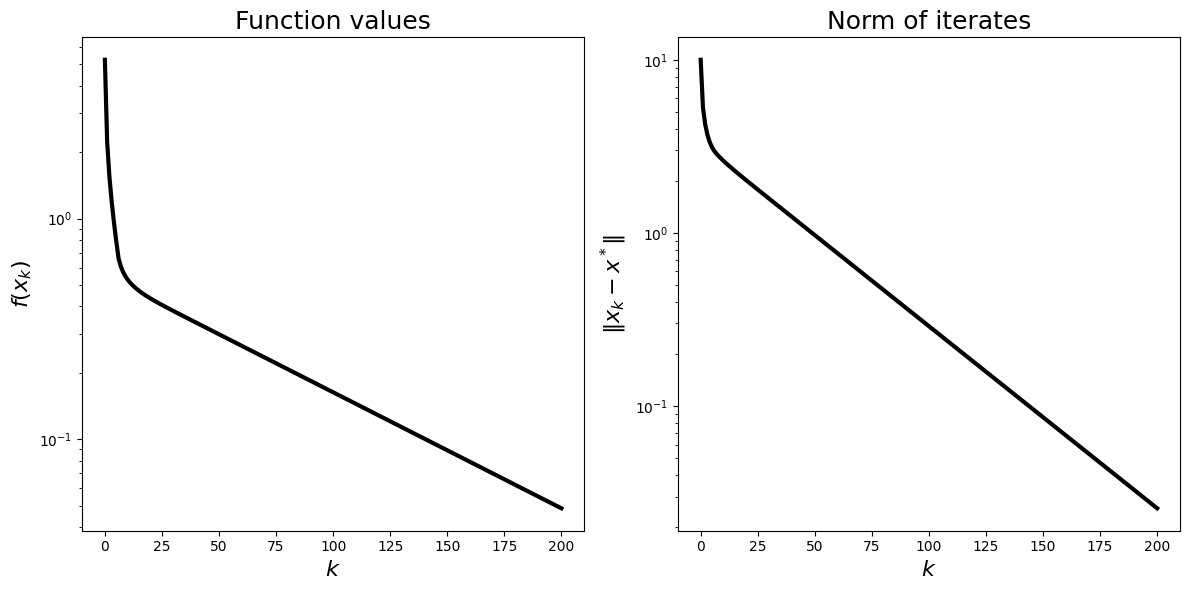

In [9]:
x_norms = np.square(np.linalg.norm(x_iter - x_star, ord=2, axis=1))
plot_fvals(f_vals, x_norms, yscale='log')

Let us now plot the sequence $\| x_k - x_{k -1} \|$

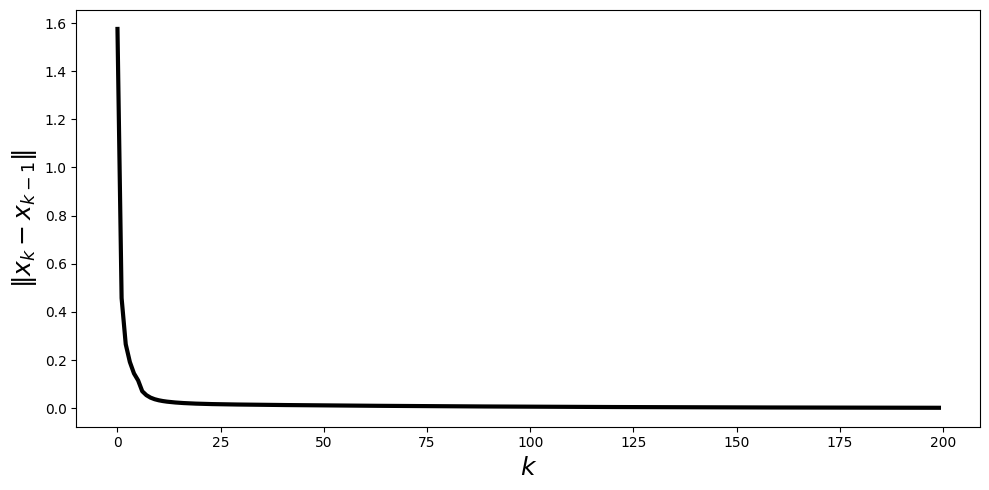

In [10]:
xk_seq = np.empty(x_iter.shape[0]-1)
for i in range(x_iter.shape[0]-1):
  xk_seq[i] = np.linalg.norm(x_iter[i + 1] - x_iter[i], ord=2)


fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(xk_seq.shape[0]), xk_seq, '-', c='black', lw=3)
ax.set_xlabel("$k$", fontsize=18)
ax.set_ylabel(r"$ \| x_k - x_{k - 1} \| $", fontsize=18)
fig.tight_layout()

## EXERCISE 2: One dimensional deconvolution
Let us consider the linear operator $\Phi$ defined as follows
$$
(\forall x \in \mathbb{R}^d) \quad \Phi x = h * x
$$
where $*$ denotes the convolution. Let
$$
\bar{h}(t) = (1 - t^2/s^2) e^{-t^2/2s^2}  \quad s>0
$$
we define $h(t) = \bar{h}(t) - \mathbb{E}[\bar{h}(t)]$. For example, let us consider the interval $[-200, 200]$ and plot the filter $h$ as a function of $t$

(-200.0, 200.0)

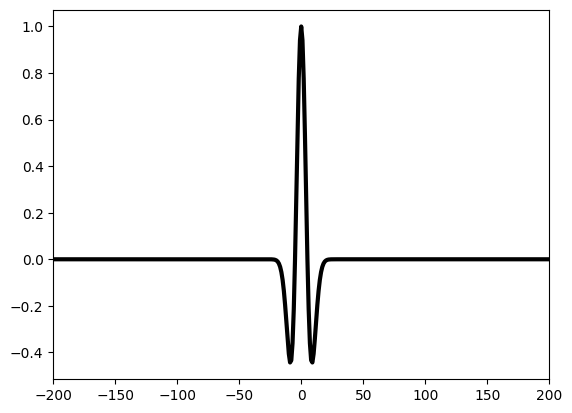

In [44]:
N = 1024

s = 5    

t = np.arange(-N/2,N/2)
h = (1-t**2/s**2)*np.exp(-(t**2)/(2*s**2))
h = h - h.mean()


fig, ax = plt.subplots()
ax.plot(t, h, '-', lw=3, c='black')
ax.set_xlim([-200, 200])

The convolution operator can be implemented as a product in the Fourier transform domain. To implement $\Phi$ we need to transform $h$ and $x$ using the Fourier transform, compute the product and transform the result using the inverse.


In [45]:
from numpy.fft import fft, fftshift, ifft # package for fast fourier transform
from numpy import real

In [46]:
h_tf = fft(fftshift(h))

def phi(x):
  return real(ifft(fft(x) * h_tf))

Let us generate the true signal (i.e. the one we will need to recover) and force the signal to have only $10$ nonzero components with values in $[-1, -0.7]$ and $[0.7, 1]$.


In [47]:
rng = np.random.default_rng(42)

s = round(N*.01) # number of nonzero elements of xsharp (1% of N)
sel = rng.permutation(N)
sel = sel[0:s]   # indices of the nonzero elements of xsharp
x_bar = np.zeros(N)
x_bar[sel] = np.sign(rng.standard_normal(s)) * (1-0.3*rng.random(s))

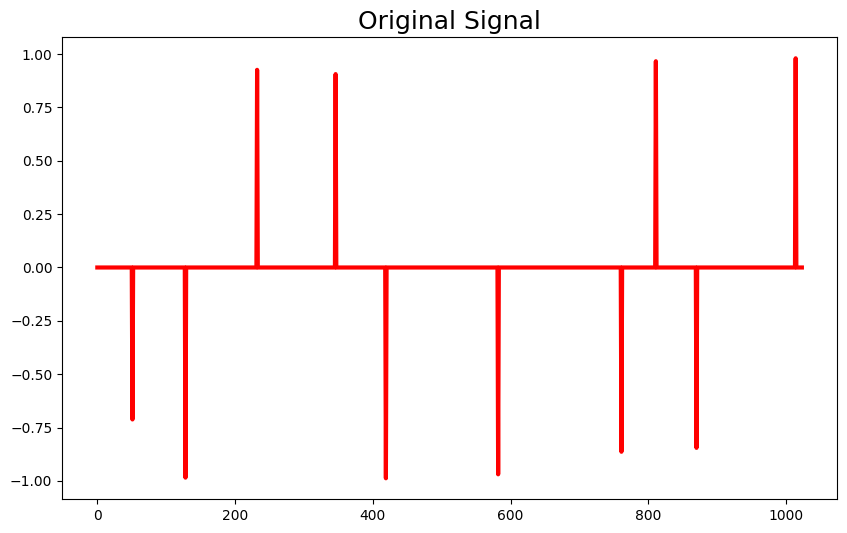

In [48]:
fig, ax = plt.subplots(figsize=(10,6))
ax.set_title("Original Signal", fontsize=18)
ax.plot(range(N), x_bar, lw=3, c='red')

Let us now add Gaussian noise with standard deviation $0.2$ and compute the observation as
$$
y = \Phi(\bar x) + \epsilon 
$$

In [49]:
noise_std = 0.2
y = phi(x_bar) + noise_std * rnd_state.randn(N)

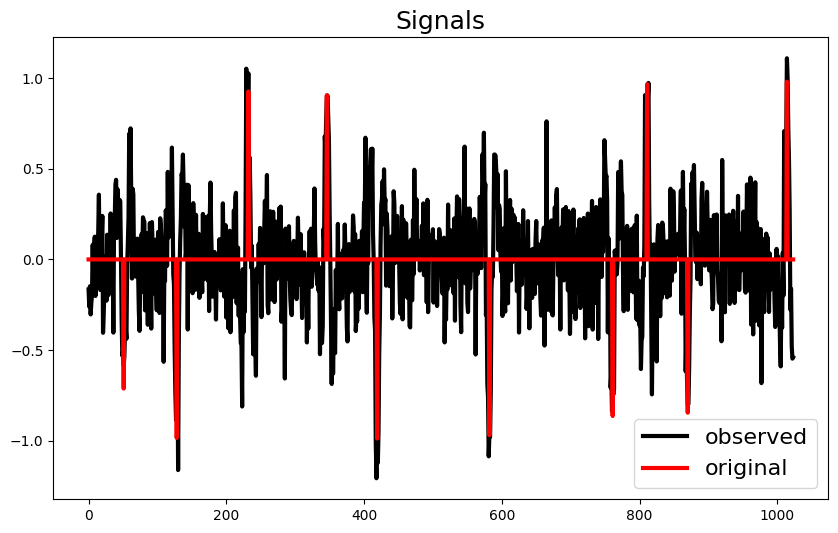

In [50]:
fig, ax = plt.subplots(figsize=(10,6))
ax.set_title("Signals", fontsize=18)
ax.plot(range(N), y, lw=3, c='black', label='observed')
ax.plot(range(N), x_bar, lw=3, c='red', label='original')
ax.legend(fontsize=16)

To recover the original signal, let us minimize the following function
$$
\min F(x) := \underbrace{\frac{1}{2} \| \Phi(x) - y \|_2^2}_{f(x)} + \underbrace{\lambda \| x \|_1}_{g(x)}.
$$
The proximal operator associated with the $\ell_1$-norm is the **soft-thresholding operator**:
$$
\operatorname{soft}_{\alpha}(x_i) =
\begin{cases}
x_i - \alpha & \text{if } x_i > \alpha \\
0 & \text{if } |x_i| \le \alpha \\
x_i + \alpha & \text{if } x_i < -\alpha
\end{cases}
$$
Equivalently, we have
$$
\operatorname{soft}_{\alpha}(x_i)
= x_i - \frac{x_i}{\max\left(1, \frac{|x_i|}{\alpha}\right)}.
$$
Note that $f$ is differentiable and (since $\Phi(x) = \Phi(x)^\intercal$) the gradient is
$$
\nabla f(x) = \Phi(\Phi(x) - y)
$$
and the Lipschitz constant is $L=\|\Phi\|^2$ which can be computed as follows 
```
L = np.max(np.abs(fft(h))) ** 2
```

Let us implement the function `F` (that given an $x$ returns the value of $f$ at $x$), the function `grad_f` (that given an $x$ returns the gradient of $f$ at $x$) and the function `soft` (that given an $x$ and an $\alpha$ returns the proximal operator)

In [51]:
def F(x, lam):
  # TODO: return the value of F at x
  return 1/2 * norm(phi(x) - y)**2 + lam * norm(x)

def grad_f(x):
  # TODO: return the gradient of f at x
  return phi(phi(x) - y)

def soft(x, alpha):
  # TODO: return the prox of g at x
  return x - x/(np.maximum(1, abs(x)/alpha))

Let us now implement the function `pg_descent` that solves the minimization problem using the proximal gradient method.

In [52]:
def pg_descent(x0, gamma, lam, max_iter = 20):
  F_vals = np.empty(max_iter + 1)
  x_iters = np.empty((max_iter + 1, x0.shape[0]))
  x = x0.copy()
  F_vals[0] = F(x0, lam)
  x_iters[0] = x.copy()
  
  for t in range(max_iter):
    # TODO: compute the forward-backward iteration 
    x = soft(x - gamma * grad_f(x), gamma*lam)

    F_vals[t + 1] = F(x, lam)
    x_iters[t + 1] = x.copy()
  return x, F_vals, x_iters

Let us run the algorithm.

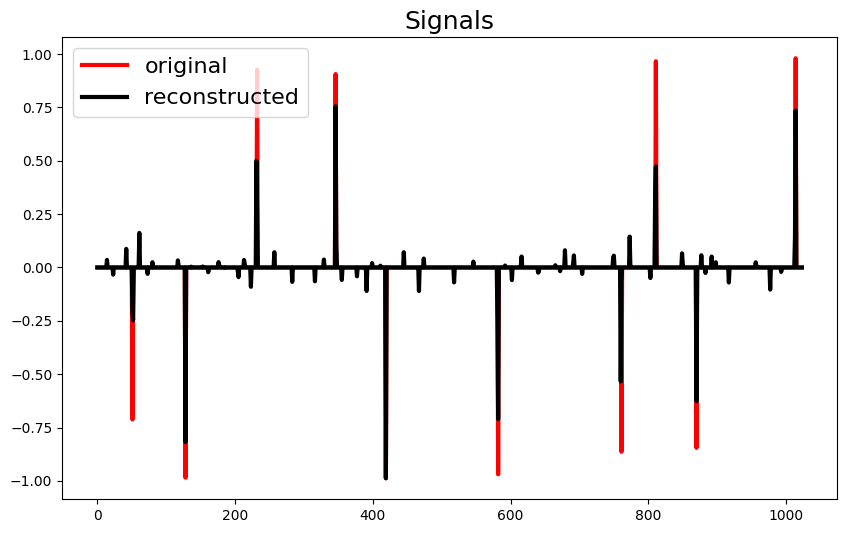

In [56]:
x0 = np.full(N, 1.0) 
lam = 0.5
max_iter = 5000
L = np.max(np.abs(fft(h))) ** 2

# TODO: set a reasonable stepsize 
gamma = 1/L

# TODO: run the algorithm 
x, F_vals, x_iters = pg_descent(x0, gamma, lam, max_iter)

# Plot the original signal and the reconstruction
fig, ax = plt.subplots(figsize=(10,6))
ax.set_title("Signals", fontsize=18)
ax.plot(range(N), x_bar, lw=3, c='red', label='original')
ax.plot(range(N), x, lw=3, c='black', label='reconstructed')
ax.legend(fontsize=16)

Let us now plot the sequence
$$
\| x_k - x^* \|
$$

Text(0, 0.5, '$\\| x_k - x^* \\|$')

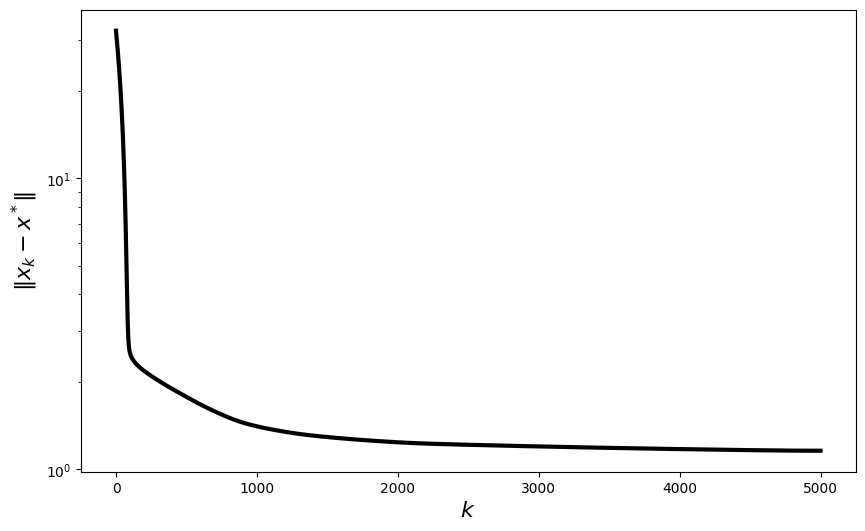

In [22]:
x_norms = np.linalg.norm(x_iters - x_bar, axis=1, ord=2)

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(range(x_norms.shape[0]), x_norms, '-', lw=3, c='black')
ax.set_yscale("log")
ax.set_xlabel("$k$", fontsize=16)
ax.set_ylabel(r"$\| x_k - x^* \|$", fontsize=16)

Try different values of $\lambda$ and observe how the reconstruction and the sequence vary $\| x_k - x^* \|$.

In [26]:
lams = [1e-2, 1e-1, 0.5, 1.0, 3.0, 5.0] 

x_iters = []
x0 = np.full(N, 1.0) 
max_iter = 10000 
L = np.max(np.abs(fft(h))) ** 2

# TODO: set a reasonable stepsize 
gamma = 1/L

for lam in lams:
  # TODO: run the algorithm 
  _, _, xs = pg_descent(x0, gamma, lam, max_iter)

  x_iters.append(xs)

Let us plot the obtained sequences.

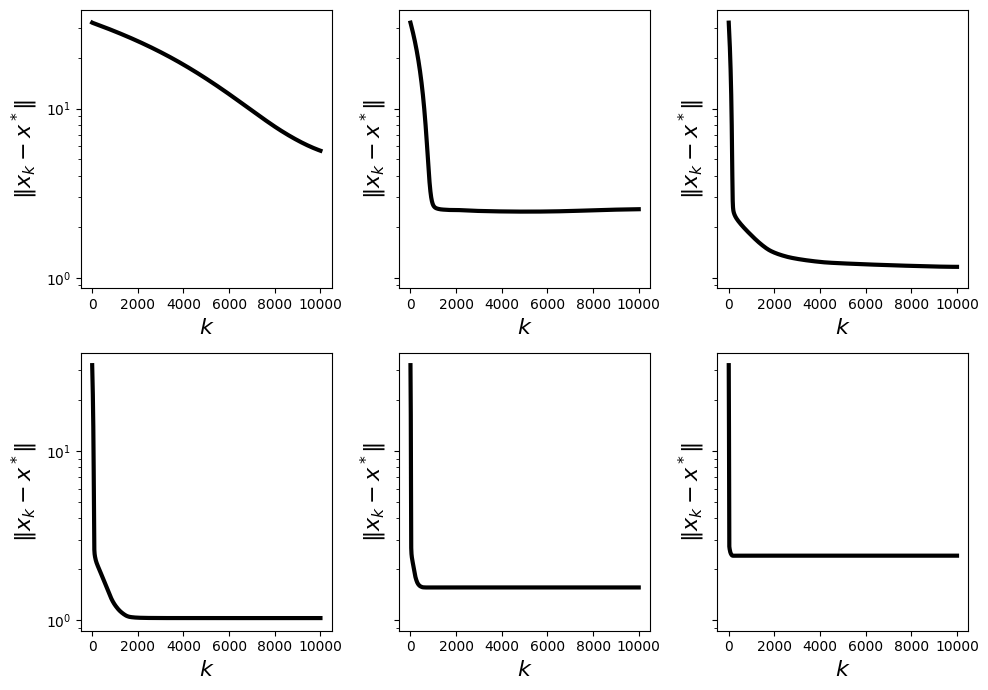

In [27]:
c = 0
fig, axs = plt.subplots(2, 3, figsize=(10, 7), sharey=True)
for i in range(axs.shape[0]):
  for j in range(axs.shape[1]):
    x_norms = np.linalg.norm(x_iters[c] - x_bar, ord=2, axis=1)
    axs[i, j].plot(x_norms, '-', c='black', lw=3)
    axs[i, j].set_yscale("log")
    axs[i, j].set_ylabel(r"$\| x_k - x^* \|$", fontsize=16)
    axs[i, j].set_xlabel("$k$", fontsize=16)
    c+=1

fig.tight_layout()

Let us plot different reconstructions.

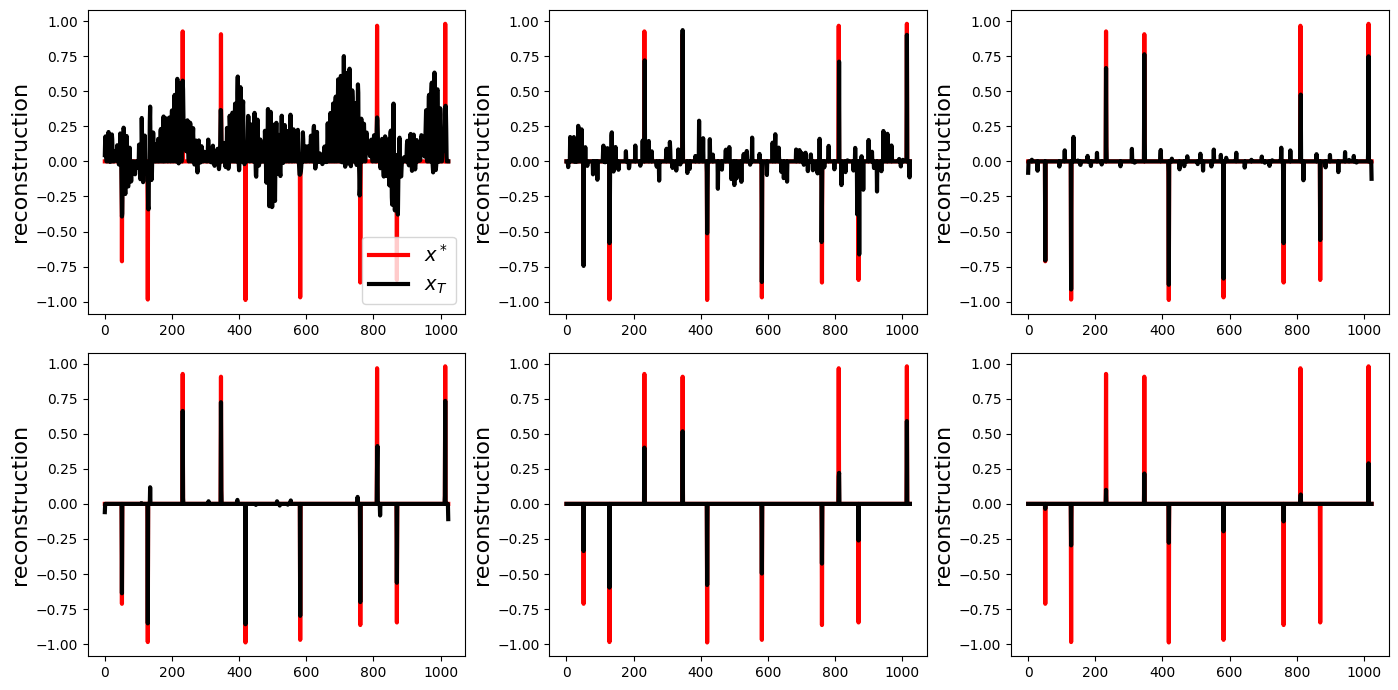

In [28]:
c = 0
fig, axs = plt.subplots(2, 3, figsize=(14, 7))
for i in range(axs.shape[0]):
  for j in range(axs.shape[1]):
    axs[i, j].plot(x_bar, '-', c='red', lw=3, label='$x^*$')
    axs[i, j].plot(x_iters[c][-1], '-', c='black', lw=3, label='$x_T$')
    axs[i, j].set_ylabel("reconstruction", fontsize=16)
    if c == 0:
      axs[i, j].legend(fontsize=14)
    c+=1

fig.tight_layout()

## EXERCISE 3: Least Squares
Let $\bar{x} \in \mathbb{R}^d$ e $A \in \mathbb{R}^{n \times d}$ with $A_{i,j} \sim \mathcal{N}(0, 1)$ for every $i,j$. 

Let us define $y = A\bar{x}$ and let us consider the following optimization problem
$$
\min\limits_{x \in \mathbb{R}^d} F(x) := \frac{1}{2} \| Ax - y \|^2.
$$
Specifically, let us consider $n = 100$ e $d =50$.



In [58]:
n = 100
d = 50

A = rnd_state.randn(n, d)
x_bar = np.ones(d)        # global optimizer
y = A @ x_bar

# TODO: implement the function F
def F(x):
  return 1/2 * norm((A @ x) - y)**2

/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/3026700865.py:6: RuntimeWarning: divide by zero encountered in matmul
  y = A @ x_bar
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/3026700865.py:6: RuntimeWarning: overflow encountered in matmul
  y = A @ x_bar
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/3026700865.py:6: RuntimeWarning: invalid value encountered in matmul
  y = A @ x_bar


### Gradient Descent

Since the function is smooth and convex, we can use gradient descent to solve the problem. 
Let us define a function `grad_F(x)` that given a point $x \in \mathbb{R}^d$ returns $\nabla F(x)$.

In [59]:
def grad_F(x):
  # TODO: return the gradient of F at x
  return A.T @ (A @ x - y)

and let us implement a function
```
gradient_descent(x0, gamma, max_iter)
```
that given an initial point $x_0 \in \mathbb{R}^d$, a step-size $\gamma > 0$ and a number of iterations max_iter > 0, returns: 
- `x`: the last iterate
- `x_iters` : a vector containing all the iterates
- `F_vals` : a vector containing the function values at each iterate

In [60]:
def gradient_descent(x0, gamma, max_iter):
  x_iters = np.empty((max_iter + 1, x0.shape[0]))
  F_vals = np.empty((max_iter + 1))
  
  x = x0.copy()
  x_iters[0] = x0.copy()
  F_vals[0] = F(x0)

  for k in range(max_iter):
    # TODO: implement the gradient descent iteration
    x = x - grad_F(x) * gamma
    
    x_iters[k + 1] = x.copy()
    F_vals[k + 1] = F(x)
  return x, x_iters, F_vals

Let us now run gradient descent

In [61]:
eigs = np.linalg.eigvalsh(A.T @ A)

# TODO: compute mu (strong convexity parameter) and L (Lipschitz constant of the gradient)
mu = min(eigs)
L = max(eigs)

# Check the value of L and mu to understand the conditioning of the problem and to choose a reasonable value for gamma
# TODO: choose an appropriate stepsize 
gamma = 2 / (mu + L) # fix a value for gamma


x0 = np.full(d, -100)
max_iter = 1000

# TODO: run the algorithm
x, gd_iters, gd_vals = gradient_descent(x0, gamma, max_iter)

/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/3794681625.py:1: RuntimeWarning: divide by zero encountered in matmul
  eigs = np.linalg.eigvalsh(A.T @ A)
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/3794681625.py:1: RuntimeWarning: overflow encountered in matmul
  eigs = np.linalg.eigvalsh(A.T @ A)
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/3794681625.py:1: RuntimeWarning: invalid value encountered in matmul
  eigs = np.linalg.eigvalsh(A.T @ A)
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/3026700865.py:10: RuntimeWarning: divide by zero encountered in matmul
  return 1/2 * norm((A @ x) - y)**2
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/3026700865.py:10: RuntimeWarning: overflow encountered in matmul
  return 1/2 * norm((A @ x) - y)**2
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/3026700865.py:10: RuntimeWarning: invalid value encountered in matmul
  return 1/2 * nor

Let us define a function to plot the results

In [62]:
# functions to plot the results 
def plot_ls_results(labels, F_vals, x_iters, x_bar):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
  for i in range(len(labels)):
    x_norms = np.linalg.norm(x_iters[i] - x_bar, ord=2, axis=1)
    ax1.plot(range(F_vals[i].shape[0]), F_vals[i], '-', lw=3, label='{}'.format(labels[i]))
    ax2.plot(range(x_norms.shape[0]), x_norms, '-', lw=3)
  ax1.set_ylabel("$F(x_k)$", fontsize=16)
  ax2.set_ylabel(r"$\| x_k - \bar{x}\|$", fontsize=16)
  ax1.set_xlabel("$k$", fontsize=16)
  ax2.set_xlabel("$k$", fontsize=16)
  ax1.set_yscale("log")
  ax2.set_yscale("log")
  ax1.legend(fontsize=12)
  fig.tight_layout()

Let us plot the sequences $F(x_k)$ and $\| x_k - \bar{x}\|$.

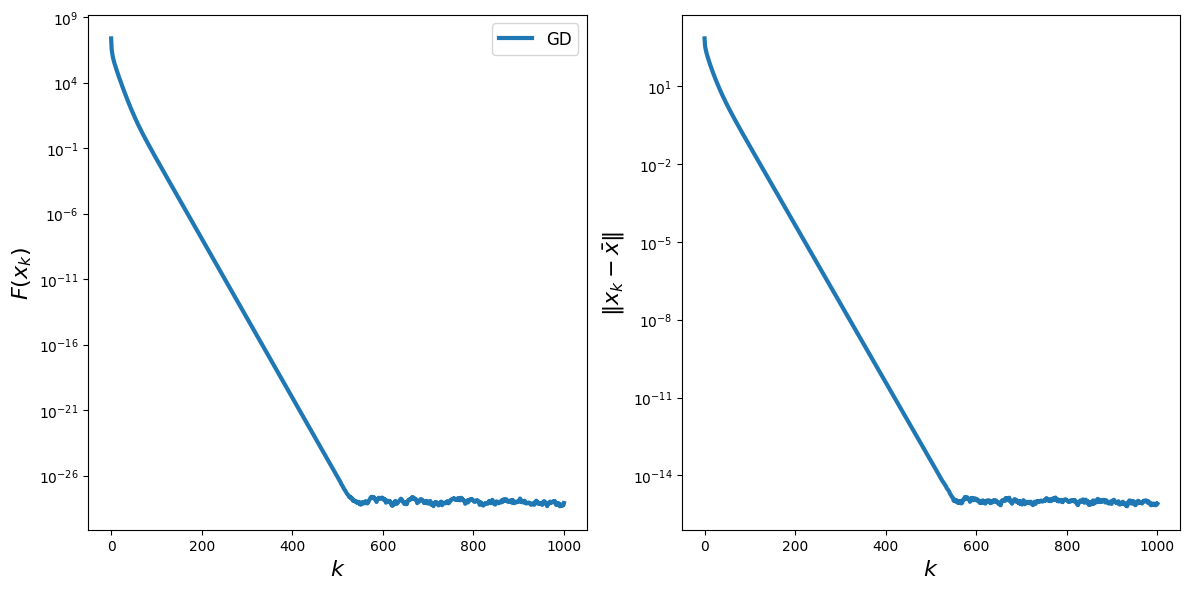

In [63]:
plot_ls_results(['GD'], [gd_vals], [gd_iters], x_bar)

### Nesterov acceleration
One way to achieve acceleration is to add an inertia term that contains information from previous iterates. This idea can be implemented with the following algorithm known as "Nesterov accelerated Gradient" (NAG): given $x_0 \in \mathbb{R}^d$, let $y_0 = x_0$, then
$$
\left\{\begin{array}{l}
x_{k + 1} = y_k - \gamma \nabla f(y_k)\\
y_{k + 1} = x_{k + 1} + \beta_{k + 1} (x_{k + 1} - x_k)
\end{array}
\right.
$$
where $\beta_{k} \geq 0$ is the inertia parameter. 

Note that the algorithm can be rewritten as follows
$$
x_{k + 1} = x_{k} + \beta_{k} (x_{k} - x_{k - 1}) - \gamma \nabla f(x_{k} + \beta_{k} (x_{k} - x_{k-1})).
$$
Furthermore, with $\beta_k = 0$ (for every $k$), we recover gradient descent.



### Inertia
In the case of strongly convex functions, the best choice of parameters (inertia and step-size) is
$$
\gamma = \frac{1}{L} \qquad \text{e}\qquad \beta_k = \frac{\sqrt{L} - \sqrt{\mu}}{\sqrt{L} + \sqrt{\mu}}
$$



Let us now implement the NAG algorithm using the function
```
nag(x0, gamma, beta, max_iter)
```
where:
- `x0`: the initial point.
- `gamma`: the step-size.
- `beta`: inertia parameter.
- `max_iter` : number of iterations.

The function should return: 
- `x`: the last iterate.
- `x_iters` : a vector containing all the iterates.
- `f_vals` : a vector containing the function values at each iterate.

In [64]:
def nag(x0,  gamma, beta, max_iter):
  x = x0.copy()
  y = x0.copy()

  x_iters = np.empty((max_iter + 1, x0.shape[0]))
  F_vals = np.empty((max_iter + 1))

  x_iters[0] = x.copy()
  F_vals[0] = F(x)

  for k in range(max_iter):

    # TODO: compute the NAG iteration
    x_next = y - (gamma * grad_F(y))
    y_next = x_next + (beta * (x_next - x))

    x = x_next
    y = y_next
    x_iters[k + 1] = x.copy()
    F_vals[k + 1] = F(x)
  return x, x_iters, F_vals

Let us now run NAG and compare the results with gradient descent.


In [65]:
# TODO: choose an appropriate stepsize 
gamma =  1 / L

# TODO: choose the inertia parameter
beta = (np.sqrt(L) - np.sqrt(mu)) / (np.sqrt(L) + np.sqrt(mu))

x0 = np.full(d, -100)
max_iter = 1000

# TODO: run the algorithm
x, nag_iters, nag_vals = nag(x0, gamma, beta, max_iter)

/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/3026700865.py:10: RuntimeWarning: divide by zero encountered in matmul
  return 1/2 * norm((A @ x) - y)**2
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/3026700865.py:10: RuntimeWarning: overflow encountered in matmul
  return 1/2 * norm((A @ x) - y)**2
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/3026700865.py:10: RuntimeWarning: invalid value encountered in matmul
  return 1/2 * norm((A @ x) - y)**2
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/2166019230.py:3: RuntimeWarning: divide by zero encountered in matmul
  return A.T @ (A @ x - y)
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/2166019230.py:3: RuntimeWarning: overflow encountered in matmul
  return A.T @ (A @ x - y)
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/2166019230.py:3: RuntimeWarning: invalid value encountered in matmul
  return A.T @ (A @ x - y)


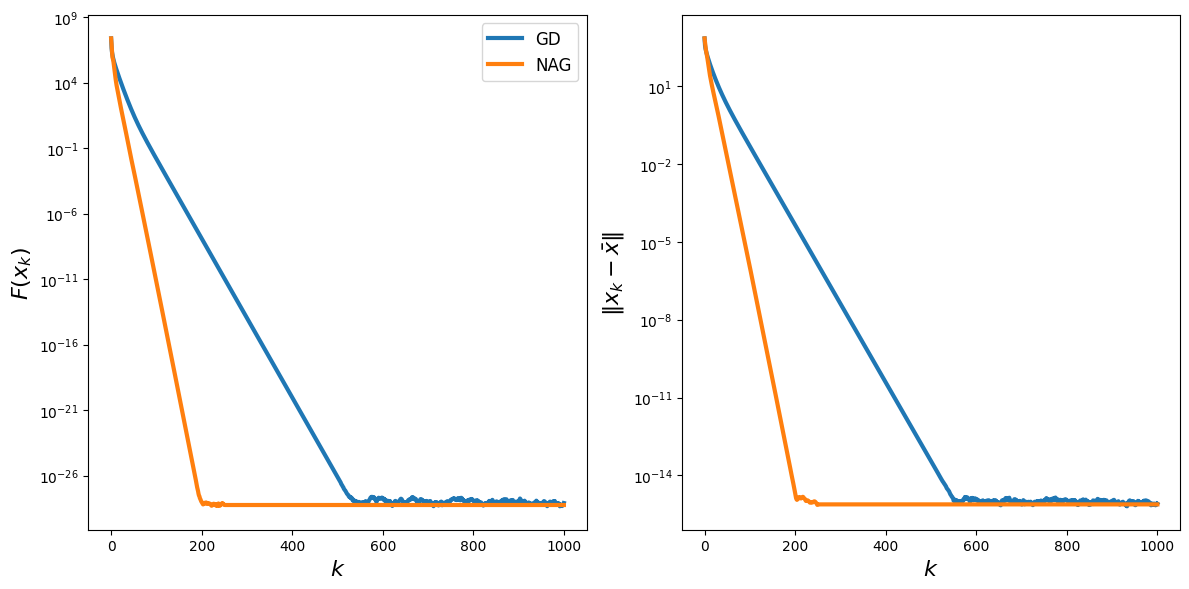

In [66]:
labels = ["GD", "NAG"]
x_iters = [gd_iters , nag_iters]
f_vals = [gd_vals, nag_vals]

plot_ls_results(labels, f_vals, x_iters, x_bar)

### Heavy-ball method
An alternative algorithm to achieve acceleration consists in including inertia only in the extrapolation (i.e. not in the gradient). Let $x_0 \in \mathbb{R}^d$ 
$$
x_{k + 1} = x_k  - \gamma \nabla f(x_k) + \underbrace{\beta_k (x_{k} - x_{k - 1})}_{\text{momentum}}.
$$

Let us implement the function 
```
hb(x0, gamma, beta, max_iter = 20)
```
where:
- `x0`: is the initial point
- `F`: the target function
- `grad_f`: function that given $x$ returns $\nabla F(x)$
- `gamma`: is the stepsize
- `beta`: is the inertia parameter
- `max_iter`: is the number of iterations

The function should return: 
- `x`: the last iterate.
- `x_iters` : a vector containing all the iterates.
- `f_vals` : a vector containing the function values at each iterate.

In [67]:
def hb(x0, gamma, beta, max_iter = 20):
  F_vals = np.empty(max_iter + 1)
  x_iters = np.empty((max_iter + 1, x0.shape[0]))
  x = x0.copy()

  F_vals[0] = F(x)
  x_iters[0] = x.copy()
  momentum = 0
  for t in range(max_iter):
    
    # TODO: compute the Heavy-ball iteration
    if t > 0:
      momentum = beta * (x - x_iters[t-1])
    x = x - gamma * grad_F(x) + momentum 

    F_vals[t + 1] = F(x) 
    x_iters[t + 1] = x.copy()
  return x, x_iters, F_vals

As seen in class, choosing
$$
\gamma = \frac{4}{(\sqrt{L} + \sqrt{\mu})^2} \qquad \text{and} \qquad \beta = \Bigg( \frac{\sqrt{L} - \sqrt{\mu}}{\sqrt{L} + \sqrt{\mu}} \Bigg)^2
$$
a better rate than GD is obtained. 

Let us run Heavy-ball and compare the result with NAG and GD (obtained previously)


In [68]:
# TODO: choose an appropriate stepsize 
gamma =  4 / (np.sqrt(L) + np.sqrt(mu))**2

# TODO: choose an appropriate inertia parameter
beta = ((np.sqrt(L) - np.sqrt(mu)) / (np.sqrt(L) + np.sqrt(mu)))**2

x0 = np.full(d, -100)
max_iter = 1000

# TODO: run the algorithm
x, hb_iters, hb_vals = hb(x0, gamma, beta, max_iter)

/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/3026700865.py:10: RuntimeWarning: divide by zero encountered in matmul
  return 1/2 * norm((A @ x) - y)**2
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/3026700865.py:10: RuntimeWarning: overflow encountered in matmul
  return 1/2 * norm((A @ x) - y)**2
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/3026700865.py:10: RuntimeWarning: invalid value encountered in matmul
  return 1/2 * norm((A @ x) - y)**2
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/2166019230.py:3: RuntimeWarning: divide by zero encountered in matmul
  return A.T @ (A @ x - y)
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/2166019230.py:3: RuntimeWarning: overflow encountered in matmul
  return A.T @ (A @ x - y)
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/2166019230.py:3: RuntimeWarning: invalid value encountered in matmul
  return A.T @ (A @ x - y)


Let us now plot the results

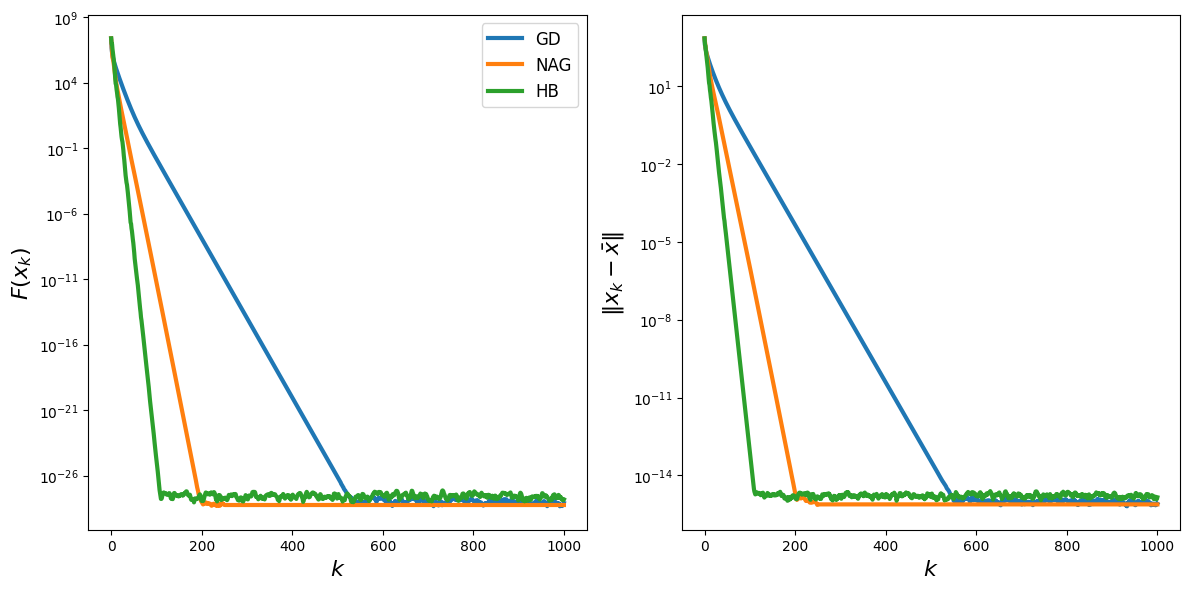

In [69]:
labels = ["GD", "NAG", "HB"]
x_iters = [gd_iters, nag_iters, hb_iters]
F_vals = [gd_vals, nag_vals, hb_vals]

plot_ls_results(labels, F_vals, x_iters, x_bar)

## EXERCISE 4: Signal Reconstruction (Lasso)
Let
$$
y = A \bar{x}
$$
where:
- $A \in \mathbb{R}^{n \times d}$ is a matrix that models an acquisition process. 
- $\bar{x} \in \mathbb{R}^d$ is some signal.
- $y \in \mathbb{R}^n$

Let us consider for example $n = 60$, $d = 200$. Furthermore, let us assume $A_{i,j} \sim \mathcal{N}(0,1)$ and that the observations have Gaussian noise
$$
\tilde{y} = y + \epsilon
$$
with $\epsilon_i \sim \mathcal{N}(0, 1)$. 




In [70]:
rng = np.random.default_rng(42)

n = 60
d = 200

A = rnd_state.randn(n, d) # matrix A
x_bar = rnd_state.randn(d) # signal to recover 

s = 10 # number of nonzero elements of x 
mask = rng.permutation(d)
mask = mask[0:s]   # indices of the nonzero elements of x
x_bar = np.zeros(d)
x_bar[mask] = np.sign(rng.standard_normal(s)) * (1-0.5*rng.random(s))

y = A @ x_bar + np.sqrt(0.1) * rnd_state.randn(n) # observation with noise

/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/994306228.py:15: RuntimeWarning: divide by zero encountered in matmul
  y = A @ x_bar + np.sqrt(0.1) * rnd_state.randn(n) # observation with noise
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/994306228.py:15: RuntimeWarning: overflow encountered in matmul
  y = A @ x_bar + np.sqrt(0.1) * rnd_state.randn(n) # observation with noise
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/994306228.py:15: RuntimeWarning: invalid value encountered in matmul
  y = A @ x_bar + np.sqrt(0.1) * rnd_state.randn(n) # observation with noise


Let us consider the problem of recovering the signal $\bar{x}$. To do so, let us consider the following problem
$$
\min\limits_{x \in \mathbb{R}^d} F(x):= \underbrace{\frac{1}{2} \| Ax - y \|^2}_{=: f(x)} + \underbrace{\lambda \| x \|_1}_{=: g(x)}
$$

Since the function $g$ is not smooth, we cannot use gradient descent to solve the problem.


In [71]:
# for simplicity, let us assume we know a "good" value for lambda
lam = 1

# TODO: implement the function F
def F(x):
  return (1/2 * norm((A @ x) - y)**2) + lam * norm(x)

As we can observe, the problem is of the form $F(x) = f(x) + g(x)$ where $f$is smooth and has an $L$-Lipschitz continuous gradient, where the constant is given by $L = \| A^\intercal A \|$.

We now implement the function `grad_F` which takes as input `x` and returns the gradient of $f$ at $x$.

In [72]:
# TODO: return the gradient of f at x
def grad_f(x):
  return A.T @ (A @ x - y)

### Forward-backward:
$$
x_{k+1} = \text{prox}_{\gamma g}(x_k - \gamma \nabla f(x_k))
$$
where the prox operator is defined as follows
$$
\text{prox}_{\gamma g}(v) := \arg \min\limits_{x \in \mathbb{R}^d} \Big\{ g(x) + \frac{1}{2 \gamma} \| x - v \|^2 \Big\}.
$$


In [73]:
def soft(x, alpha):
  # TODO: compute the prox of g at x
  return x - x/(np.maximum(1, abs(x)/alpha))

# Implementation of Forward-Backward
def prox_grad(x0, gamma, max_iter = 20):
  F_vals = np.empty(max_iter + 1)
  x_iters = np.empty((max_iter + 1, x0.shape[0]))
  x = x0.copy()
  F_vals[0] = F(x)
  x_iters[0] = x.copy()
  
  for t in range(max_iter):
    # TODO: compute the forward-backward iteration
    x = soft(x - gamma * grad_f(x), gamma * lam)

    F_vals[t + 1] = F(x) 
    x_iters[t + 1] = x.copy()
  return x,  x_iters, F_vals  

In [75]:
x0 = np.full(d, 10) 
max_iter = 2000

eigs = np.linalg.eigvalsh(A.T @ A)
L = eigs[-1]

# TODO: set a reasonable stepsize 
gamma = 1 / L

# TODO: run the algorithm 
_, pg_x_iters, pg_Fvals = prox_grad(x0, gamma, max_iter)

/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/2262419761.py:4: RuntimeWarning: divide by zero encountered in matmul
  eigs = np.linalg.eigvalsh(A.T @ A)
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/2262419761.py:4: RuntimeWarning: overflow encountered in matmul
  eigs = np.linalg.eigvalsh(A.T @ A)
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/2262419761.py:4: RuntimeWarning: invalid value encountered in matmul
  eigs = np.linalg.eigvalsh(A.T @ A)
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/2604352834.py:6: RuntimeWarning: divide by zero encountered in matmul
  return (1/2 * norm((A @ x) - y)**2) + lam * norm(x)
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/2604352834.py:6: RuntimeWarning: overflow encountered in matmul
  return (1/2 * norm((A @ x) - y)**2) + lam * norm(x)
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/2604352834.py:6: RuntimeWarning: invalid value encount

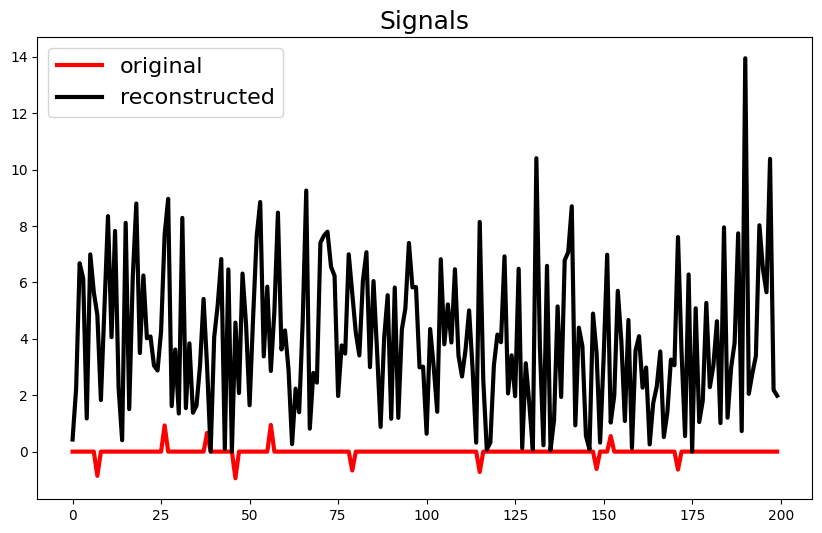

In [76]:
fig, ax = plt.subplots(figsize=(10,6))
ax.set_title("Signals", fontsize=18)
ax.plot(range(d), x_bar, lw=3, c='red', label='original')
ax.plot(range(d), pg_x_iters[-1], lw=3, c='black', label='reconstructed')
ax.legend(fontsize=16)

Plot the values and the iterates of forward-backward

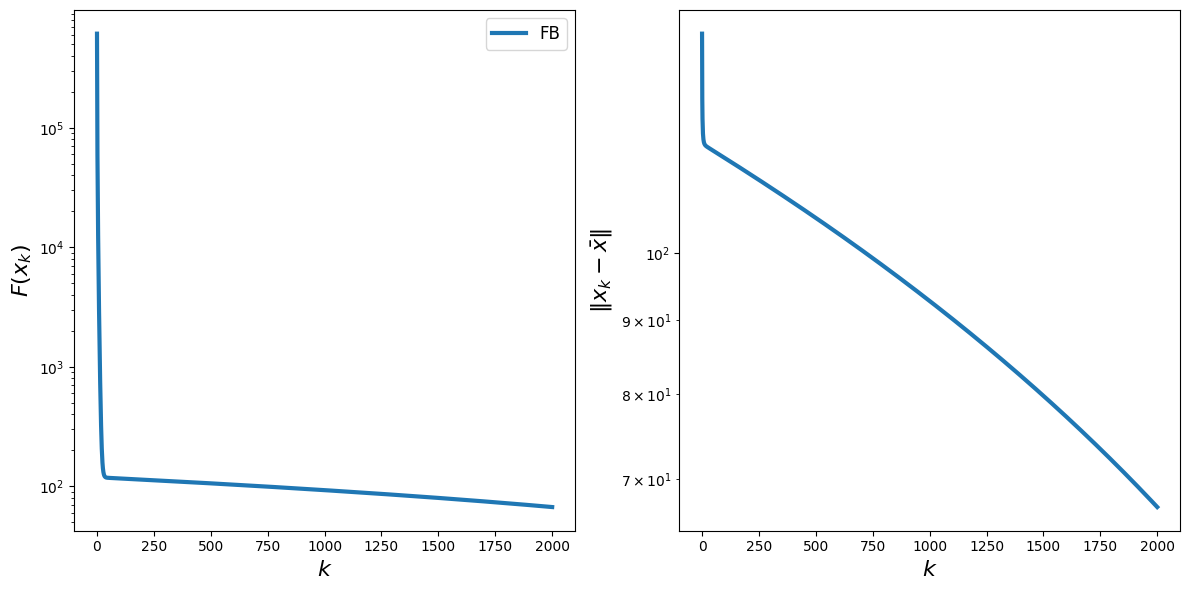

In [77]:
labels = ['FB']

x_iters = [pg_x_iters]
F_vals = [pg_Fvals]

plot_ls_results(labels, F_vals, x_iters, x_bar)

### Heavy-ball
We can extend heavy-ball by including the prox. Let $x_0 \in \mathbb{R}^d$, 
$$
x_{k + 1} = \text{prox}_{\gamma g}(x_k + \beta_k (x_{k} - x_{k - 1}) - \gamma \nabla f(x_k))
$$
Note that for $\beta_k = 0$, the algorithm is identical to proximal gradient.


In [78]:
def heavy_ball(x0, gamma, beta, max_iter = 20):
  F_vals = np.empty(max_iter + 1)
  x_iters = np.empty((max_iter + 1, x0.shape[0]))
  x = x0.copy()
  F_vals[0] = F(x)
  x_iters[0] = x.copy()
  momentum = 0

  for t in range(max_iter):
    # TODO: compute the Heavy-ball iteration
    if t > 0:
      momentum = beta * (x - x_iters[t-1])
    x = soft(x - gamma * grad_F(x) + momentum, gamma * lam)

    F_vals[t + 1] = F(x) 
    x_iters[t + 1] = x.copy()
  return x, x_iters, F_vals

Run HB with different values of $\beta \in (0, 1)$ and compare the performance with subgradient method and forward-backward

In [79]:
betas = [0.0, 0.1, 0.5, 0.9]

hb_iters = []
hb_vals = []

for beta in betas:
  
  # TODO: run the algorithm
  _, hb_x_iters, hb_Fvals = heavy_ball(x0, gamma, beta, max_iter=1000)

  hb_iters.append(hb_x_iters)
  hb_vals.append(hb_Fvals)

/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/2604352834.py:6: RuntimeWarning: divide by zero encountered in matmul
  return (1/2 * norm((A @ x) - y)**2) + lam * norm(x)
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/2604352834.py:6: RuntimeWarning: overflow encountered in matmul
  return (1/2 * norm((A @ x) - y)**2) + lam * norm(x)
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/2604352834.py:6: RuntimeWarning: invalid value encountered in matmul
  return (1/2 * norm((A @ x) - y)**2) + lam * norm(x)
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/2166019230.py:3: RuntimeWarning: divide by zero encountered in matmul
  return A.T @ (A @ x - y)
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/2166019230.py:3: RuntimeWarning: overflow encountered in matmul
  return A.T @ (A @ x - y)
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/2166019230.py:3: RuntimeWarning: invalid value encountere

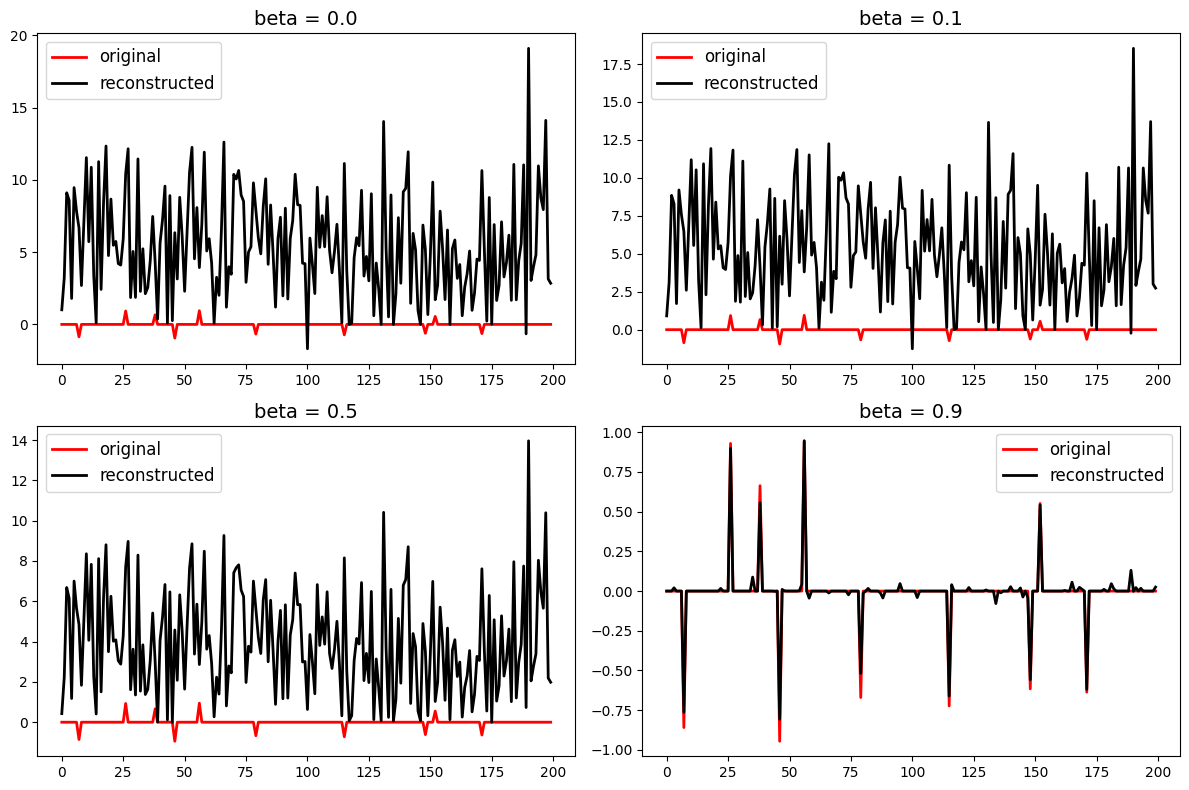

In [80]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))  
axes = axes.flatten()  
for i, beta in enumerate(betas):
    ax = axes[i]
    ax.set_title(f"beta = {beta}", fontsize=14)
    ax.plot(range(d), x_bar, lw=2, c='red', label='original')
    ax.plot(range(d), hb_iters[i][-1], c='black', lw=2, label='reconstructed')
    ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

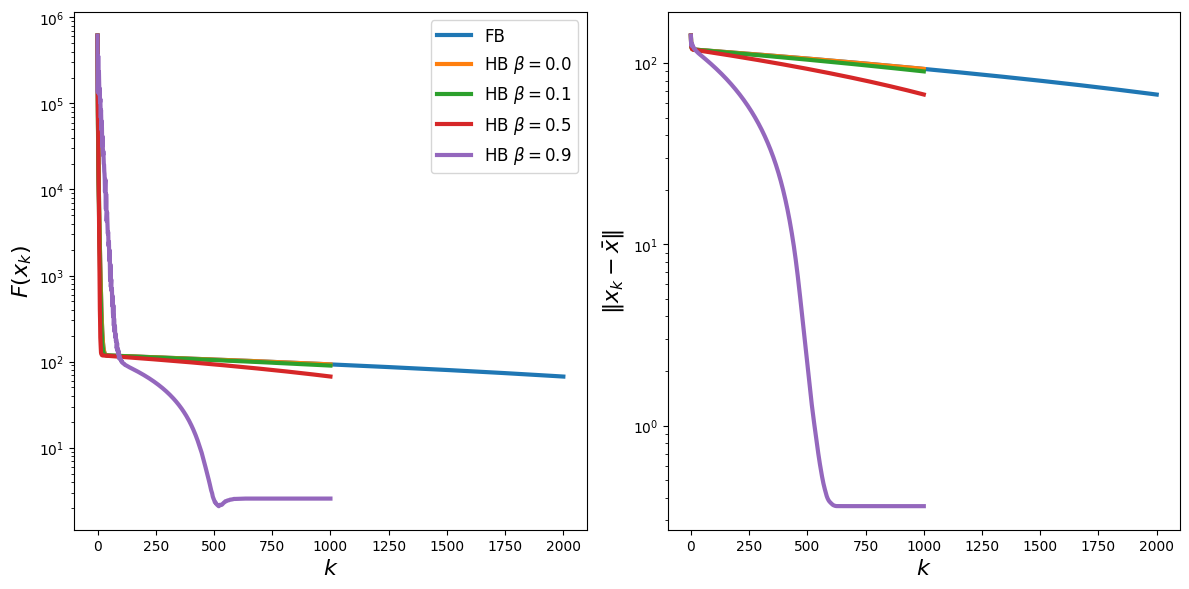

In [81]:
labels = ['FB'] + ['HB $\\beta = {}$'.format(beta) for beta in betas]

x_iters = [pg_x_iters] + hb_iters
F_vals = [pg_Fvals] + hb_vals

plot_ls_results(labels, F_vals, x_iters, x_bar)

### Nesterov Acceleration: FISTA
We can also extend NAG by including the prox. The resulting algorithm is called "Fast Iterative Soft Thresholding Algorithm"(FISTA).
$$
\left\{\begin{array}{l}
x_{k + 1} = \text{prox}_{\gamma g}(y_k - \gamma \nabla f(y_k))\\
y_{k + 1} = x_{k + 1} + \beta_{k + 1} (x_{k + 1} - x_k)
\end{array}
\right.
$$



**Inertia**

In the literature, several inertia parameters have been proposed. Specifically, the parameter $\beta_k$ is generally chosen as
$$
\beta_{k + 1} = \frac{t_k - 1}{t_{k + 1}}
$$
where $t_k$ is a sequence that (in order to obtain acceleration) must satisfy the following condition
$$
t_{k + 1}^2 - t_{k + 1} - t_k^2 \leq 0
$$
In particular, in this lab we will consider two cases:
- Nesterov (Beck & Teboulle): let $t_0 = 1$ and
$$
t_{k + 1} = \frac{1 + \sqrt{1 + 4 t_k^2}}{2}
$$
- Chambolle & Dossal: let $t_0 = 1$ and 
$$
t_{k + 1} = \frac{k + 1 + \alpha }{\alpha}
$$
with $\alpha > 0$.

Note that the condition for acceleration is satisfied (as an equality) in the Nesterov case, and it is also satisfied for the Chambolle proposal when $\alpha \geq 2$. Furthermore, the two proposals are “equivalent” when $\alpha = 2$.

Let us define two functions that implement the proposed schemes:
- `get_beta_nest`: takes as input $t_k$ and $k$ and returns $\beta_{k}$ e $t_{k + 1}$ using the Nesterov sequence.
- `get_beta_chamb`: takes as input $\alpha > 0$ and returns a function that takes as input $t_k$ and $k$ and returns $\beta_k$ e $t_{k + 1}$ using the second strategy.


In [ ]:
def get_beta_nest(tk, k):

  # TODO: return beta_k using the Nesterov sequence
  t_next = (1 + np.sqrt(1 + 4 * tk**2)) / 2
  beta = (tk - 1) / t_next

  return beta, t_next

def get_beta_chamb(alpha):
  def get_beta(tk, k):

    # TODO: return beta_{k+1} using the Chambolle-Dossal sequence
    t_next = (k + 1 + (alpha)) / (alpha)
    beta = (tk - 1) / t_next

    return beta, t_next
  return get_beta

Let us implement the function `fista` that computes the proposed iteration. This function will take the following parameters:
```
fista(x0, gamma, compute_beta, max_iter)
```
Where:
- `x0`: the initial point.
- `gamma`: the step-size.
- `compute_beta`: function that computes the inertia parameter.
- `max_iter` : number of iterations.

The function should return: 
- `x`: the last iterate.
- `x_iters` : a vector containing all the iterates.
- `F_vals` : a vector containing the function values at each iterate.



In [83]:
def fista(x0, gamma, compute_beta, max_iter = 20):
  x = x0.copy()
  y = x0.copy()

  x_iters = np.empty((max_iter + 1, x0.shape[0]))
  F_vals = np.empty((max_iter + 1))

  x_iters[0] = x.copy()
  F_vals[0] = F(x)

  tk = 1
  for k in range(max_iter):

    beta_k, t_next = compute_beta(tk, k)

    # TODO: compute the NAG iteration
    x_next = soft(y - gamma * grad_f(y), gamma * lam)
    y_next = x_next + beta_k * (x_next - x)

    tk = t_next

    x = x_next
    y = y_next
    x_iters[k + 1] = x.copy()
    F_vals[k + 1] = F(x)
  return x, x_iters, F_vals

Let us compare now FISTA with subgradient method and forward-backward considering both schemes for the inertia parameter (Nesterov, Chambolle & Dossal) and using different values of $\alpha$.


In [84]:
# TODO: run fista with beta calcolato con Nesterov method
_, nest_x_iters, nest_Fvals = fista(x0, gamma, get_beta_nest, max_iter=1000)

alphas = [2, 5, 10, 100] 

ch_iters = []
ch_vals = []

for alpha in alphas:
  
  # TODO: run fista with beta calcolato con Chambolle & Dossal method
  _, ch_x_iters, ch_Fvals = fista(x0, gamma, get_beta_chamb(alpha), max_iter=1000)

  ch_iters.append(ch_x_iters)
  ch_vals.append(ch_Fvals)

/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/2604352834.py:6: RuntimeWarning: divide by zero encountered in matmul
  return (1/2 * norm((A @ x) - y)**2) + lam * norm(x)
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/2604352834.py:6: RuntimeWarning: overflow encountered in matmul
  return (1/2 * norm((A @ x) - y)**2) + lam * norm(x)
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/2604352834.py:6: RuntimeWarning: invalid value encountered in matmul
  return (1/2 * norm((A @ x) - y)**2) + lam * norm(x)
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/228485249.py:3: RuntimeWarning: divide by zero encountered in matmul
  return A.T @ (A @ x - y)
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/228485249.py:3: RuntimeWarning: overflow encountered in matmul
  return A.T @ (A @ x - y)
/var/folders/1c/76y4hnt50xqdcckcrsd6y7ww0000gn/T/ipykernel_46999/228485249.py:3: RuntimeWarning: invalid value encountered i

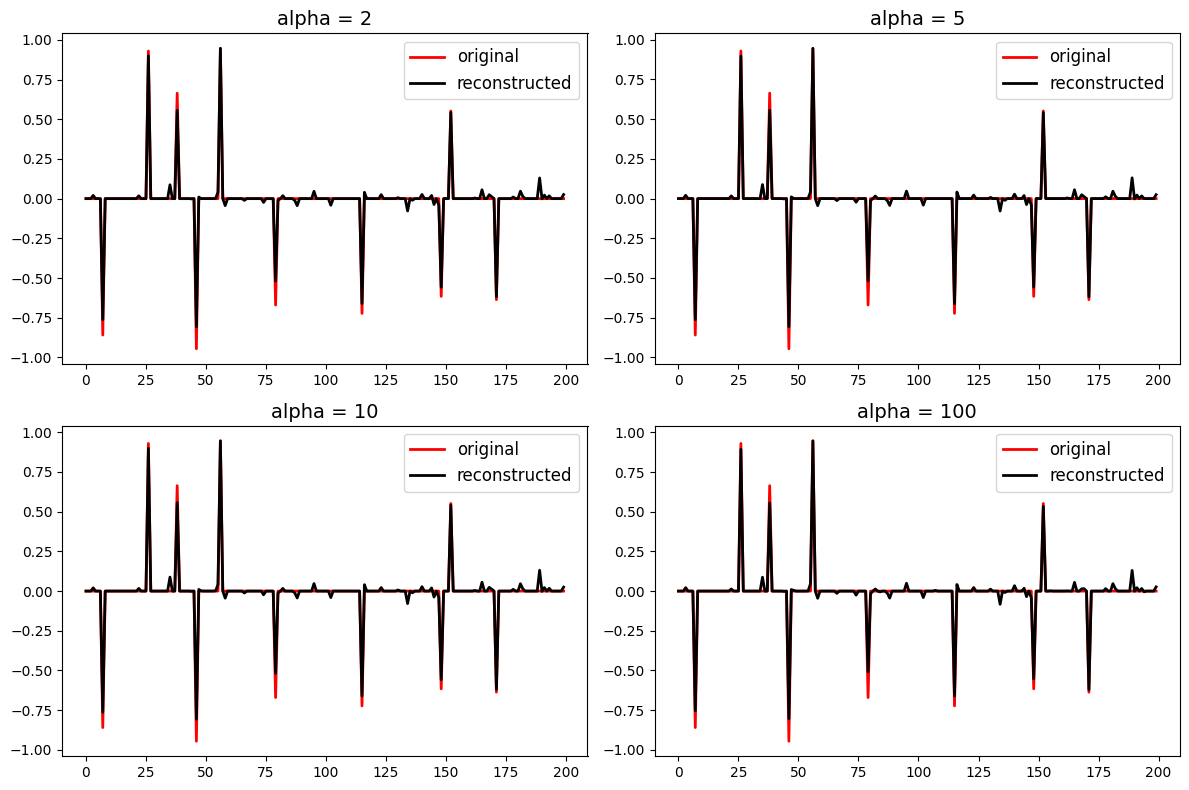

In [85]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))  
axes = axes.flatten()  
for i, alpha in enumerate(alphas):
    ax = axes[i]
    ax.set_title(f"alpha = {alpha}", fontsize=14)
    ax.plot(range(d), x_bar, lw=2, c='red', label='original')
    ax.plot(range(d), ch_iters[i][-1], c='black', lw=2, label='reconstructed')
    ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

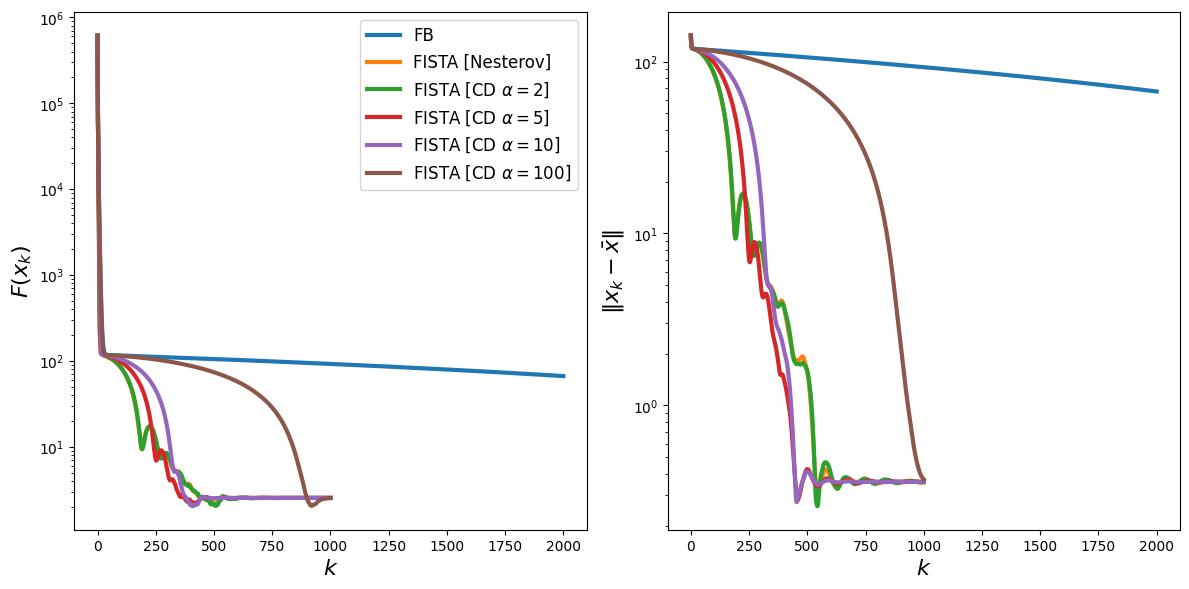

In [86]:
labels = ['FB', 'FISTA [Nesterov]'] + ['FISTA [CD $\\alpha = {}$]'.format(alpha) for alpha in alphas]

x_iters = [pg_x_iters, nest_x_iters] + ch_iters
F_vals = [pg_Fvals, nest_Fvals] + ch_vals

plot_ls_results(labels, F_vals, x_iters, x_bar)